Bài tập thực hành 3 (Bổ sung): Phân đoạn hình ảnh bằng K-Means (K-Means Image Segmentation)
Bài toán: Phân đoạn một hình ảnh cho trước thành K cụm bằng thuật toán K-means.



tải ảnh bằng pil

In [18]:
#import thư viện PIL để đọc và xử lý ảnh
from PIL import Image

# Đọc ảnh từ file
image = Image.open("chua.png")
#chuyển anh sang định dạng RGB
image = image.convert("RGB")
print(image.size)

(1170, 585)


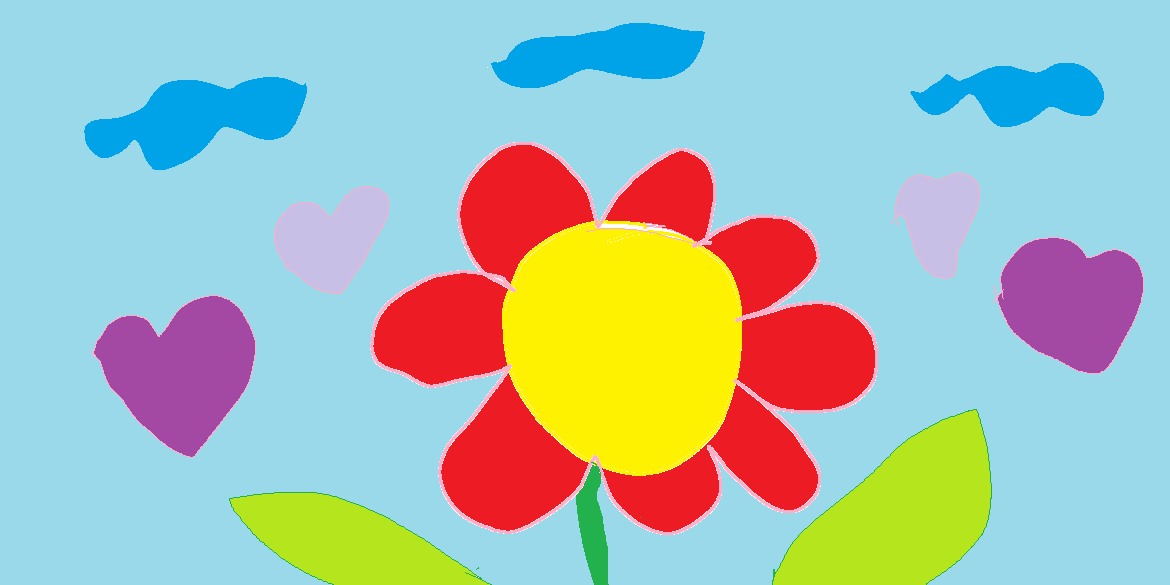

In [19]:
#xuất ảnh ra để kiểm tra bằng PIL

display(image)

In [20]:
from PIL import Image, ImageOps

def resize_with_padding(img, target_size=(224, 224), color=(0, 0, 0)):
    target_w, target_h = target_size

    w, h = img.size

    scale = min(target_w / w, target_h / h)

    new_w = int(w * scale)
    new_h = int(h * scale)

    img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)

    return img

In [21]:
img = resize_with_padding(image)

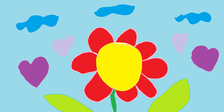

In [22]:
display(img)

In [23]:
import numpy as np
pixels = np.array(img)
print(pixels.shape)

(112, 224, 3)


In [24]:
pixels = pixels.reshape(-1,3)

print("Shape sau flatten:")
print(pixels.shape)

print("\n10 pixel đầu tiên:")
print(pixels[:10])

Shape sau flatten:
(25088, 3)

10 pixel đầu tiên:
[[153 217 234]
 [153 217 234]
 [153 217 234]
 [153 217 234]
 [153 217 234]
 [153 217 234]
 [153 217 234]
 [153 217 234]
 [153 217 234]
 [153 217 234]]


In [74]:
import numpy as np
from PIL import Image


class KMeansImage:

    def __init__(self, k=4, max_iter=20, tol=1e-3):
        self.k = k
        self.max_iter = max_iter
        self.tol = tol

        self.centroids = None
        self.labels = None

    # ==========================================
    # Khởi tạo centroid ngẫu nhiên
    # ==========================================
    def initialize_centroids(self, pixels):

        indices = np.random.choice(
            len(pixels),
            self.k,
            replace=False
        )

        self.centroids = pixels[indices].astype(float)

        print("\nINITIAL CENTROIDS")
        print("-" * 50)

        for i, c in enumerate(self.centroids):
            print(f"C{i}: {c}")

    # ==========================================
    # Gán pixel vào centroid gần nhất
    # ==========================================
    def assign_clusters(self, pixels):

        distances = np.linalg.norm(
            pixels[:, np.newaxis] - self.centroids,
            axis=2
        )

        labels = np.argmin(distances, axis=1)

        return labels

    # ==========================================
    # Tính centroid mới
    # ==========================================
    def update_centroids(self, pixels, labels):

        new_centroids = []

        for k in range(self.k):

            cluster_pixels = pixels[labels == k]

            if len(cluster_pixels) == 0:

                centroid = self.centroids[k]

            else:

                centroid = cluster_pixels.mean(axis=0)

            new_centroids.append(centroid)

        return np.array(new_centroids)

    # ==========================================
    # Huấn luyện
    # ==========================================
    def fit(self, pixels, watch_pixel=None):

        self.initialize_centroids(pixels)

        for iteration in range(self.max_iter):

            print("\n")
            print("=" * 60)
            print(f"ITERATION {iteration + 1}")
            print("=" * 60)

            old_centroids = self.centroids.copy()

            # -----------------------------
            # Assign Cluster
            # -----------------------------
            labels = self.assign_clusters(pixels)

            self.labels = labels

            print("\nPIXELS PER CLUSTER")

            for k in range(self.k):

                count = np.sum(labels == k)

                print(
                    f"Cluster {k}: {count} pixels"
                )

            # -----------------------------
            # Theo dõi 1 pixel
            # -----------------------------
            if watch_pixel is not None:

                pixel_value = pixels[watch_pixel]

                cluster_id = labels[watch_pixel]

                print("\nWATCH PIXEL")

                print(
                    f"Index : {watch_pixel}"
                )

                print(
                    f"RGB   : {pixel_value}"
                )

                print(
                    f"Cluster Assigned : {cluster_id}"
                )

            # -----------------------------
            # Update Centroid
            # -----------------------------
            self.centroids = self.update_centroids(
                pixels,
                labels
            )

            print("\nCENTROID UPDATE")

            for i in range(self.k):

                print("\nCluster", i)

                print(
                    "Old:",
                    np.round(old_centroids[i], 2)
                )

                print(
                    "New:",
                    np.round(self.centroids[i], 2)
                )

            # -----------------------------
            # Kiểm tra hội tụ
            # -----------------------------
            shift = np.linalg.norm(
                self.centroids - old_centroids
            )

            print(
                f"\nCentroid Shift = {shift:.6f}"
            )

            if shift < self.tol:

                print("\nKMEANS CONVERGED")
                break

        return self

    # ==========================================
    # Nén ảnh
    # ==========================================
    def compress(self, pixels):

        labels = self.assign_clusters(pixels)

        compressed_pixels = (
            self.centroids[labels]
            .astype(np.uint8)
        )

        return compressed_pixels


# ====================================================
# MAIN
# ====================================================

image_path = "f95aed8502aa31e208630a20b28c808c.jpg"

img = Image.open(image_path).convert("RGB")

# resize ảnh
img = resize_with_padding(img)

img_array = np.array(img)

h, w, c = img_array.shape

print("Image Shape:", img_array.shape)

# flatten
pixels = img_array.reshape(-1, 3)

print("Pixels Shape:", pixels.shape)

# nhập K
K = int(input("Nhap so cum K: "))

model = KMeansImage(
    k=K,
    max_iter=200
)

# theo dõi pixel thứ 500
model.fit(
    pixels,
    watch_pixel=500
)

compressed_pixels = model.compress(
    pixels
)

compressed_img = compressed_pixels.reshape(
    h,
    w,
    3
)

compressed_img = Image.fromarray(
    compressed_img
)

compressed_img.save(
    "compressed.jpg"
)

print("\nSaved: compressed.jpg")

Image Shape: (168, 224, 3)
Pixels Shape: (37632, 3)

INITIAL CENTROIDS
--------------------------------------------------
C0: [183. 147.   0.]
C1: [68. 68. 13.]
C2: [178. 160.  68.]
C3: [41. 51. 43.]
C4: [233. 215.  36.]
C5: [213. 187.  28.]
C6: [92. 88. 12.]
C7: [58. 57.  7.]
C8: [225. 212. 166.]
C9: [51. 52. 49.]
C10: [220. 222. 146.]
C11: [218. 213. 160.]
C12: [217. 175.  51.]
C13: [98. 96. 24.]
C14: [253. 242. 129.]
C15: [66. 54. 12.]
C16: [17. 18. 13.]
C17: [34. 16.  0.]
C18: [30. 30. 10.]
C19: [77. 67. 14.]


ITERATION 1

PIXELS PER CLUSTER
Cluster 0: 914 pixels
Cluster 1: 779 pixels
Cluster 2: 3560 pixels
Cluster 3: 610 pixels
Cluster 4: 528 pixels
Cluster 5: 493 pixels
Cluster 6: 708 pixels
Cluster 7: 2063 pixels
Cluster 8: 1614 pixels
Cluster 9: 767 pixels
Cluster 10: 837 pixels
Cluster 11: 614 pixels
Cluster 12: 1060 pixels
Cluster 13: 3447 pixels
Cluster 14: 406 pixels
Cluster 15: 1585 pixels
Cluster 16: 10458 pixels
Cluster 17: 1617 pixels
Cluster 18: 4315 pixels
Cluster 19

In [76]:
print("\nFINAL CENTROIDS")

for i, c in enumerate(model.centroids):

    print(
        f"C{i}: {np.round(c,2)}"
    )


FINAL CENTROIDS
C0: [180.96 146.86  44.49]
C1: [72.15 63.9  14.96]
C2: [153.52 151.45  90.26]
C3: [38.94 45.7  42.79]
C4: [232.73 217.02  71.72]
C5: [211.97 181.88  37.9 ]
C6: [144.81 117.18  36.5 ]
C7: [49.25 41.5   9.33]
C8: [246.71 246.52 235.55]
C9: [68.9  79.28 64.78]
C10: [223.94 213.63 132.57]
C11: [150.4 177.  157.5]
C12: [198.95 181.55  90.85]
C13: [110.95 120.31  76.47]
C14: [226.36 225.1  191.27]
C15: [159.25  55.34  27.72]
C16: [8.07 7.23 4.78]
C17: [84.58 22.51  7.31]
C18: [27.93 23.31  9.85]
C19: [103.86  89.21  26.54]


In [77]:
original_colors = len(
    np.unique(pixels, axis=0)
)

compressed_colors = len(
    np.unique(
        compressed_pixels,
        axis=0
    )
)

print(
    "Original colors:",
    original_colors
)

print(
    "Compressed colors:",
    compressed_colors
)

Original colors: 27479
Compressed colors: 20


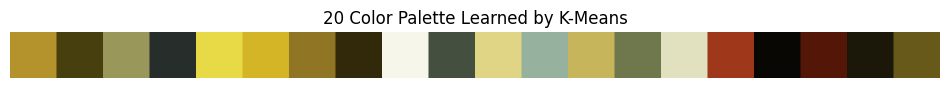

In [78]:
import matplotlib.pyplot as plt
import numpy as np

centroids = np.array(model.centroids)

palette = np.zeros((50, len(centroids) * 50, 3),
                   dtype=np.uint8)

for i, color in enumerate(centroids):

    palette[:, i*50:(i+1)*50] = color

plt.figure(figsize=(12,2))
plt.imshow(palette)
plt.axis("off")
plt.title("20 Color Palette Learned by K-Means")
plt.show()

In [80]:
unique_labels = np.unique(model.labels)

print(unique_labels)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


In [81]:
for k in range(K):

    count = np.sum(model.labels == k)

    print(k, count)

0 1915
1 2908
2 810
3 907
4 737
5 1028
6 1545
7 3920
8 531
9 717
10 1139
11 390
12 1204
13 1097
14 1176
15 364
16 8759
17 808
18 5617
19 2060


In [82]:
dominant = np.argmax([
    np.sum(model.labels == k)
    for k in range(K)
])

print(
    "Dominant Color:",
    model.centroids[dominant]
)

Dominant Color: [8.06610344 7.22696655 4.77623016]


k=30

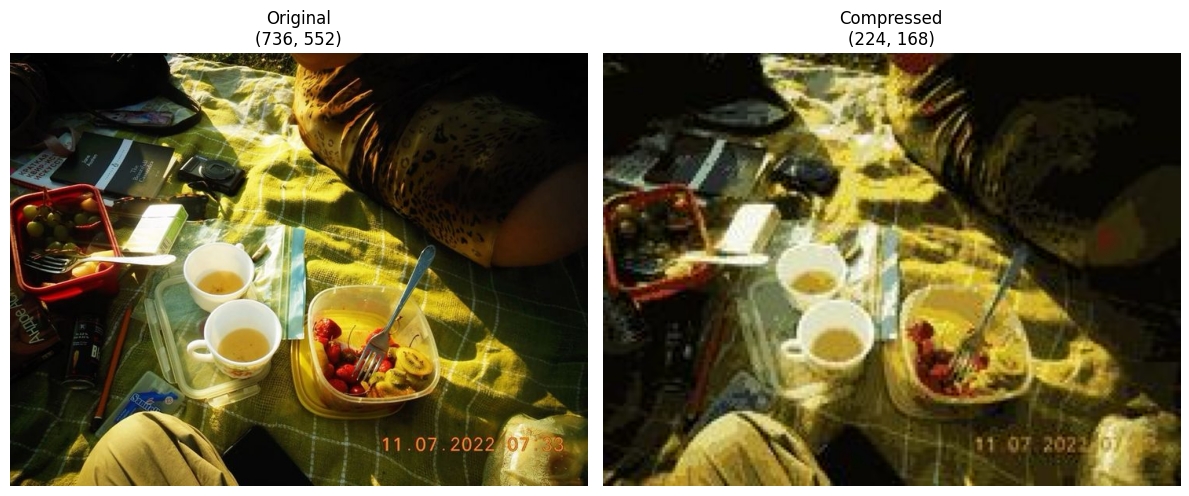

In [83]:
import matplotlib.pyplot as plt
from PIL import Image

# Ảnh gốc
img_original = Image.open("f95aed8502aa31e208630a20b28c808c.jpg")

# Ảnh nén
img_compressed = Image.open("compressed.jpg")

plt.figure(figsize=(12, 6))

# Ảnh gốc
plt.subplot(1, 2, 1)
plt.imshow(img_original)
plt.title(f"Original\n{img_original.size}")
plt.axis("off")

# Ảnh nén
plt.subplot(1, 2, 2)
plt.imshow(img_compressed)
plt.title(f"Compressed\n{img_compressed.size}")
plt.axis("off")

plt.tight_layout()
plt.show()